
          EVALUATION METRICS
SRCC                 : 0.9617
PLCC                 : 0.9504
RMSE                 : 0.3151
KRCC                 : 0.8452
---------------------------------------
Krasula Methodology Metrics:
D/S AUC              : 0.8361
B/W AUC              : 0.9927
B/W CC               : 0.9655
---------------------------------------
Avg Inference Time   : 0.0000 seconds/run



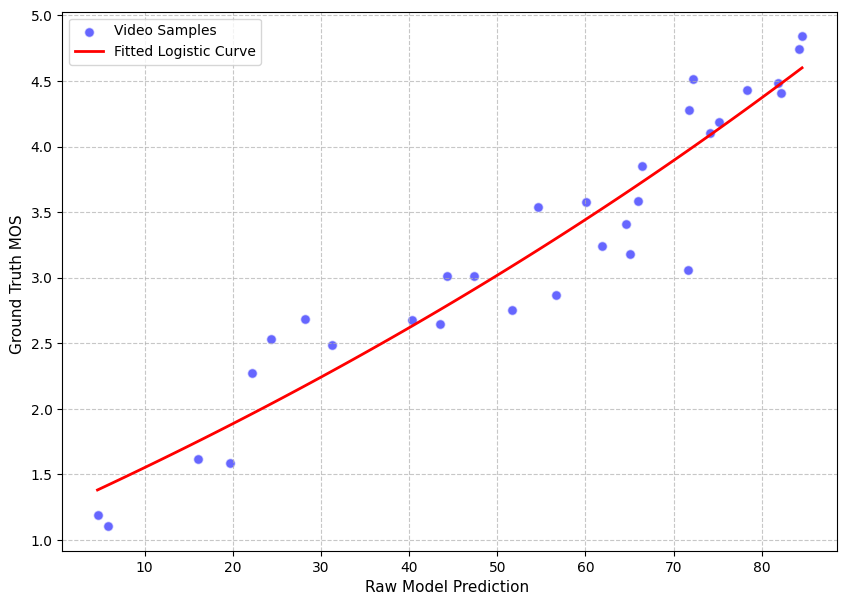

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.stats import spearmanr, pearsonr, kendalltau
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, roc_auc_score

obs_csv = "/home/padhya/codes/test_flat/UniformT_P64_KF128_PromptF_v1/inference_results_robust.csv"
ref_csv = "/data/padhya/QoMEX/QoMEX-GC/split_videos/combined_test_val.csv"

SIMILAR_MOS_THRESHOLD = 0.25 

df_obs = pd.read_csv(obs_csv)
df_obs['video_name'] = df_obs['video_name'].astype(str).str.replace(r'\.mp4$', '', regex=True)

df_avg_obs = df_obs.groupby('video_name', as_index=False)['avg_predicted_score'].mean()
df_avg_obs.rename(columns={'avg_predicted_score': 'AverageScore'}, inplace=True)

if 'inference time' in df_obs.columns:
    avg_inference_time = df_obs['inference time'].dropna().mean()
elif 'inference_time' in df_obs.columns:
    avg_inference_time = df_obs['inference_time'].dropna().mean()
else:
    avg_inference_time = 0.0

df_ref = pd.read_csv(ref_csv)
df_ref = df_ref[['video_name', 'mos']]

df_combined = pd.merge(df_avg_obs, df_ref, on='video_name', how='inner')

if df_combined.empty:
    raise ValueError('No matching videos found between the inference and reference CSVs.')

y_pred = df_combined['AverageScore'].values
y_true = df_combined['mos'].values

def logistic_4_param(x, b1, b2, b3, b4):
    x_shifted = np.clip(-(x - b3) / np.abs(b4), -500, 500)
    return (b1 - b2) / (1 + np.exp(x_shifted)) + b2

b1_guess = np.max(y_true)
b2_guess = np.min(y_true)
b3_guess = np.mean(y_pred)
b4_guess = np.std(y_pred) / 4.0 if np.std(y_pred) > 0 else 1.0
beta0 = [b1_guess, b2_guess, b3_guess, b4_guess]

mapping_successful = False
try:
    optimized_betas, _ = curve_fit(logistic_4_param, y_pred, y_true, p0=beta0, maxfev=10000)
    y_pred_mapped = logistic_4_param(y_pred, *optimized_betas)
    mapping_successful = True
except RuntimeError:
    y_pred_mapped = y_pred

srcc, _ = spearmanr(y_pred, y_true, nan_policy='omit')
krcc, _ = kendalltau(y_pred, y_true, nan_policy='omit')
plcc, _ = pearsonr(y_pred_mapped, y_true)
rmse = np.sqrt(np.nanmean((y_true - y_pred_mapped)**2))

def compute_krasula_metrics(mos, mapped_preds, threshold):
    pairs = list(itertools.combinations(range(len(mos)), 2))
    delta_mos = np.array([mos[i] - mos[j] for i, j in pairs])
    delta_pred = np.array([mapped_preds[i] - mapped_preds[j] for i, j in pairs])
    
    labels_ds = (np.abs(delta_mos) > threshold).astype(int)
    scores_ds = np.abs(delta_pred)
    try:
        auc_ds = roc_auc_score(labels_ds, scores_ds)
    except ValueError:
        auc_ds = np.nan
        
    diff_mask = (labels_ds == 1)
    delta_mos_diff = delta_mos[diff_mask]
    delta_pred_diff = delta_pred[diff_mask]
    
    labels_bw = (delta_mos_diff > 0).astype(int)
    scores_bw = delta_pred_diff
    try:
        auc_bw = roc_auc_score(labels_bw, scores_bw)
    except ValueError:
        auc_bw = np.nan
        
    preds_bw = (delta_pred_diff > 0).astype(int)
    cc_bw = np.mean(preds_bw == labels_bw) if len(labels_bw) > 0 else np.nan
    
    return auc_ds, auc_bw, cc_bw

auc_ds, auc_bw, cc_bw = compute_krasula_metrics(y_true, y_pred_mapped, SIMILAR_MOS_THRESHOLD)

# === 5. Output ===
print('\n=======================================')
print('          EVALUATION METRICS')
print('=======================================')
print(f'SRCC                 : {srcc:.4f}')
print(f'PLCC                 : {plcc:.4f}')
print(f'RMSE                 : {rmse:.4f}')
print(f'KRCC                 : {krcc:.4f}')
print('---------------------------------------')
print('Krasula Methodology Metrics:')
print(f'D/S AUC              : {auc_ds:.4f}')
print(f'B/W AUC              : {auc_bw:.4f}')
print(f'B/W CC               : {cc_bw:.4f}')
print('---------------------------------------')
print(f'Avg Inference Time   : {avg_inference_time:.4f} seconds/run')
print('=======================================\n')


if mapping_successful:
    plt.figure(figsize=(10, 7))
    plt.scatter(y_pred, y_true, s=50, c='blue', edgecolors='white', alpha=0.6, label='Video Samples')
    
    x_smooth = np.linspace(np.min(y_pred), np.max(y_pred), 100)
    y_smooth = logistic_4_param(x_smooth, *optimized_betas)
    
    plt.plot(x_smooth, y_smooth, 'r-', linewidth=2, label='Fitted Logistic Curve')

    plt.xlabel('Raw Model Prediction ', fontsize=11)
    plt.ylabel('Ground Truth MOS ', fontsize=11)
    
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plot_filename = 'vqa_scatter_plot_python.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')